## データ生成部分

In [60]:
import numpy as np
import matplotlib.pyplot as plt

N = 40
F = 8.0

def L96(x, t, F=8.0):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def rk4(f, x0, t, F=8.0):
    x = np.zeros((len(t), *x0.shape))
    x[0] = x0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        k1 = f(x[i-1], t[i-1], F)
        k2 = f(x[i-1] + 0.5 * dt * k1, t[i-1] + 0.5 * dt, F)
        k3 = f(x[i-1] + 0.5 * dt * k2, t[i-1] + 0.5 * dt, F)
        k4 = f(x[i-1] + dt * k3, t[i-1] + dt, F)
        x[i] = x[i-1] + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    return x

def gaspari_cohn(d, c):
    r = abs(d) / c
    if r <= 1.0:
        return 1.0 - (5.0/3.0)*r**2 + (5.0/8.0)*r**3 + (1.0/2.0)*r**4 - (1.0/4.0)*r**5
    elif r <= 2.0:
        return 4.0 - 5.0*r + (5.0/3.0)*r**2 + (5.0/8.0)*r**3 - (1.0/2.0)*r**4 + (1.0/12.0)*r**5 - (2.0/3.0)*(1.0/r)
    else:
        return 0.0

def get_localization_matrix(N, sigma):
    L = np.zeros((N, N))
    c = np.sqrt(10.0/3.0) * sigma 
    for i in range(N):
        for j in range(N):
            dist = min(abs(i - j), N - abs(i - j))
            L[i, j] = gaspari_cohn(dist, c)
    return L

L_matrix = get_localization_matrix(N, sigma=4)

rng = np.random.default_rng(seed=42)

## 真値と観測データの生成
x_minus90 = np.full(N, F)
x_minus90[19] = F + 1.001
spinup_days = 360
t_spinup = np.arange(0.0, spinup_days / 5, 0.05)
x_spinup = rk4(L96, x_minus90, t_spinup, F=F)
t_truth = np.arange(0.0, spinup_days / 5, 0.05)
x_truth = rk4(L96, x_spinup[-1], t_truth, F=F)

H = np.eye(N)
R = np.eye(N) * 1.0
R_inv = np.linalg.inv(R)
num_obs = N
ensembles = 8
inflation = 0.01
ensemble_init = np.zeros((N, ensembles))

y_observe = x_truth @ H.T + rng.standard_normal(size=x_truth.shape)

noise = rng.standard_normal(size=(N, ensembles))
noise = noise - np.mean(noise, axis=1, keepdims=True) 
for i in range(ensembles):
    member_x = x_spinup[-1] + noise[:, i]
    member_x_spinup = rk4(L96, member_x, t_spinup, F=F)
    ensemble_init[:, i] = member_x_spinup[-1]

## 通常LETKF

In [13]:
def run_letkf_minimal(
    ensemble_init,
    y_observe,
    x_truth,
    t_truth,
    H,
    R_inv,
    sigma_loc,
    F=8.0,
    inflation=0.0,
    eps=1e-12,
):
    """
    元のLETKFセルから最小変更で関数化した NumPy版 LETKF。

    Returns
    -------
    history_X_analysis : list
        各時刻の解析アンサンブル。step 0 は初期アンサンブル。
    inflation_history : list
        各時刻の inflation。固定値なので定数列。
    rmse_history : list
        step=1 以降の解析平均RMSE。
    """

    history_X_analysis = [ensemble_init.copy()]
    curr_X_analysis = ensemble_init.copy()

    N, ensembles = ensemble_init.shape

    inflation_history = [inflation]
    rmse_history = []

    for step in range(1, len(t_truth)):
        t_step = t_truth[step - 1 : step + 1]

        curr_X_background = rk4(L96, curr_X_analysis, t_step, F=F)[-1]

        x_background_mean = np.mean(curr_X_background, axis=1)
        Z_background = (
            curr_X_background - x_background_mean[:, None]
        ) / np.sqrt(ensembles - 1)

        Z_background = Z_background * (1.0 + inflation)
        Y_background = H @ Z_background

        d_ob = y_observe[step] - H @ x_background_mean
        next_X_analysis = np.zeros_like(curr_X_analysis)

        # 局所解析ステップ
        for j in range(N):
            # 元コード通り、毎回ここで局所化重みを作る
            dist = np.minimum(
                np.abs(np.arange(N) - j),
                N - np.abs(np.arange(N) - j),
            )

            loc_weight = np.exp(-(dist**2) / (2.0 * sigma_loc**2))

            R_loc_inv = np.diag(loc_weight) @ R_inv

            Pa_inv = np.eye(ensembles) + Y_background.T @ R_loc_inv @ Y_background

            eigenvalues, eigenvectors = np.linalg.eigh(Pa_inv)

            # ほぼ最小変更だが、数値誤差で0以下になるのを防ぐ
            eigenvalues = np.maximum(eigenvalues, eps)

            Pa = eigenvectors @ np.diag(1.0 / eigenvalues) @ eigenvectors.T
            Pa_sqrt = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T

            w_mean = Pa @ Y_background.T @ R_loc_inv @ d_ob

            W_pert = np.sqrt(ensembles - 1) * Pa_sqrt

            T_matrix = np.outer(w_mean, np.ones(ensembles)) + W_pert

            next_X_analysis[j, :] = (
                x_background_mean[j] + Z_background[j, :] @ T_matrix
            )

        curr_X_analysis = next_X_analysis
        history_X_analysis.append(curr_X_analysis.copy())
        inflation_history.append(inflation)

        x_ana_mean = np.mean(curr_X_analysis, axis=1)
        rmse = np.sqrt(np.mean((x_ana_mean - x_truth[step]) ** 2))
        rmse_history.append(float(rmse))

    return history_X_analysis, inflation_history, rmse_history

## 静的RTPS

In [22]:
def run_letkf_fixed_rtps(
    ensemble_init,
    y_observe,
    x_truth,
    t_truth,
    H,
    R_inv,
    sigma_loc,
    F=8.0,
    inflation=0.0,
    alpha=0.8,
    rtps_factor_min=0.1,
    rtps_factor_max=10.0,
    eps=1e-12,
):
    """
    NumPy版 LETKF + 固定 alpha の RTPS inflation を実行する関数。
    局所化重みは元の LETKF コードと同じく、各格子点ごとに関数内で作成する。

    Parameters
    ----------
    ensemble_init : ndarray, shape (N, ensembles)
        初期アンサンブル。
    y_observe : ndarray, shape (time, num_obs)
        観測値。
    x_truth : ndarray, shape (time, N)
        真値。RMSE計算用。
    t_truth : ndarray
        同化時刻配列。
    H : ndarray, shape (num_obs, N)
        線形観測演算子。
    R_inv : ndarray, shape (num_obs, num_obs)
        観測誤差共分散行列 R の逆行列。
    sigma_loc : float
        ガウス局所化のスケール。
    F : float
        Lorenz96 の forcing parameter。
    inflation : float
        LETKF 前に背景摂動へかける multiplicative inflation。
        実際には perturbation に (1 + inflation) を掛ける。
        純粋な LETKF + RTPS にしたい場合は 0.0。
    alpha : float
        固定 RTPS relaxation parameter。
        alpha=0 なら RTPS なし。
        alpha=1 なら analysis spread を prior spread まで戻す。
    rtps_factor_min, rtps_factor_max : float
        RTPS係数の数値安定化用クリップ範囲。
    eps : float
        0除算防止用。

    Returns
    -------
    history_X_analysis : list of ndarray
        各時刻の解析アンサンブル。step 0 は初期アンサンブル。
    alpha_history : list of float
        各時刻の alpha。固定値なので定数列。step 0 も含む。
    rmse_history : list of float
        step=1 以降の解析平均RMSE。step 0 は含まない。
    """

    history_X_analysis = [ensemble_init.copy()]
    curr_X_analysis = ensemble_init.copy()

    N, ensembles = ensemble_init.shape

    alpha_history = [alpha]
    rmse_history = []

    sqrt_m1 = np.sqrt(ensembles - 1)

    for step in range(1, len(t_truth)):
        t_step = t_truth[step - 1 : step + 1]

        # 1. 予報ステップ
        curr_X_background = rk4(L96, curr_X_analysis, t_step, F=F)[-1]

        # 2. 背景平均・背景摂動
        x_background_mean = np.mean(curr_X_background, axis=1)

        Xb_pert = curr_X_background - x_background_mean[:, None]

        # optional multiplicative inflation
        Xb_pert = (1.0 + inflation) * Xb_pert

        # LETKF用の正規化済み背景摂動
        Z_background = Xb_pert / sqrt_m1

        # RTPS用に prior perturbation を保存
        Z_prior = Z_background.copy()

        # 観測空間の背景摂動
        Y_background = H @ Z_background

        # innovation
        d_ob = y_observe[step] - H @ x_background_mean

        next_X_analysis = np.zeros_like(curr_X_analysis)

        # 3. 局所解析ステップ
        for j in range(N):
            # 元コード通り、毎回ここで局所化重みを作る
            dist = np.minimum(
                np.abs(np.arange(N) - j),
                N - np.abs(np.arange(N) - j),
            )

            loc_weight = np.exp(-(dist**2) / (2.0 * sigma_loc**2))

            R_loc_inv = np.diag(loc_weight) @ R_inv

            Pa_inv = np.eye(ensembles) + Y_background.T @ R_loc_inv @ Y_background

            eigenvalues, eigenvectors = np.linalg.eigh(Pa_inv)

            # 数値誤差対策
            eigenvalues = np.maximum(eigenvalues, eps)

            Pa = eigenvectors @ np.diag(1.0 / eigenvalues) @ eigenvectors.T
            Pa_sqrt = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T

            w_mean = Pa @ Y_background.T @ R_loc_inv @ d_ob

            W_pert = sqrt_m1 * Pa_sqrt

            T_matrix = np.outer(w_mean, np.ones(ensembles)) + W_pert

            next_X_analysis[j, :] = (
                x_background_mean[j] + Z_background[j, :] @ T_matrix
            )

        # 4. temporary analysis
        xa_mean = np.mean(next_X_analysis, axis=1)
        Xa_pert_tmp = next_X_analysis - xa_mean[:, None]

        # 正規化済み analysis perturbation
        Z_analysis_tmp = Xa_pert_tmp / sqrt_m1

        # 5. 固定 alpha で RTPS inflation
        # Z は正規化済みなので spread = sqrt(sum(Z**2))
        sigma_b_state = np.sqrt(
            np.sum(Z_prior**2, axis=1, keepdims=True)
        )
        sigma_a_state = np.sqrt(
            np.sum(Z_analysis_tmp**2, axis=1, keepdims=True)
        )

        rtps_factor = 1.0 + alpha * (
            sigma_b_state - sigma_a_state
        ) / (sigma_a_state + eps)

        rtps_factor = np.clip(rtps_factor, rtps_factor_min, rtps_factor_max)

        # RTPSを掛ける対象は正規化なしの解析摂動
        Xa_pert_inf = Xa_pert_tmp * rtps_factor

        curr_X_analysis = xa_mean[:, None] + Xa_pert_inf

        # 6. 保存
        history_X_analysis.append(curr_X_analysis.copy())
        alpha_history.append(alpha)

        x_ana_mean = np.mean(curr_X_analysis, axis=1)
        rmse = np.sqrt(np.mean((x_ana_mean - x_truth[step]) ** 2))
        rmse_history.append(float(rmse))

    return history_X_analysis, alpha_history, rmse_history

## 動的RTPS LETKF

In [19]:
def run_letkf_acr_rtps(
    ensemble_init,
    y_observe,
    x_truth,
    t_truth,
    H,
    R_inv,
    sigma_loc,
    F=8.0,
    inflation=0.0,
    initial_alpha=1.0,
    tau=1.0,
    alpha_min=0.0,
    rtps_factor_min=0.1,
    rtps_factor_max=10.0,
    eps=1e-12,
):
    """
    NumPy版 LETKF + ACR/RTPS inflation を実行する関数。
    局所化重みは各格子点ごとに関数内で作成する。

    tau:
        alpha の時間平滑化係数。
        tau=1.0 なら平滑化なし。
        tau=0.03 ならかなり強い平滑化。
    """

    history_X_analysis = [ensemble_init.copy()]
    curr_X_analysis = ensemble_init.copy()

    N, ensembles = ensemble_init.shape
    num_obs = H.shape[0]

    alpha_smooth = initial_alpha
    alpha_history = [float(alpha_smooth)]
    alpha_diagnosed_history = []
    rmse_history = []

    sqrt_m1 = np.sqrt(ensembles - 1)

    for step in range(1, len(t_truth)):
        t_step = t_truth[step - 1 : step + 1]

        # 1. 予報ステップ
        curr_X_background = rk4(L96, curr_X_analysis, t_step, F=F)[-1]

        # 2. background mean / perturbation
        x_background_mean = np.mean(curr_X_background, axis=1)

        Xb_pert = curr_X_background - x_background_mean[:, None]

        # optional multiplicative inflation
        Xb_pert = (1.0 + inflation) * Xb_pert

        # LETKF 用の正規化済み摂動
        Z_background = Xb_pert / sqrt_m1

        # RTPS 用に prior perturbation を保存
        Z_prior = Z_background.copy()

        # background perturbation in observation space
        Y_background = H @ Z_background

        # innovation
        Hxb_mean = H @ x_background_mean
        d_ob = y_observe[step] - Hxb_mean

        next_X_analysis = np.zeros_like(curr_X_analysis)

        # 3. LETKF 局所解析
        for j in range(N):
            dist = np.minimum(
                np.abs(np.arange(N) - j),
                N - np.abs(np.arange(N) - j),
            )

            loc_weight = np.exp(-(dist**2) / (2.0 * sigma_loc**2))
            R_loc_inv = np.diag(loc_weight) @ R_inv

            Pa_inv = np.eye(ensembles) + Y_background.T @ R_loc_inv @ Y_background

            eigenvalues, eigenvectors = np.linalg.eigh(Pa_inv)
            eigenvalues = np.maximum(eigenvalues, eps)

            Pa = eigenvectors @ np.diag(1.0 / eigenvalues) @ eigenvectors.T
            Pa_sqrt = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T

            w_mean = Pa @ Y_background.T @ R_loc_inv @ d_ob
            W_pert = sqrt_m1 * Pa_sqrt

            T_matrix = np.outer(w_mean, np.ones(ensembles)) + W_pert

            next_X_analysis[j, :] = (
                x_background_mean[j] + Z_background[j, :] @ T_matrix
            )

        # 4. temporary analysis
        xa_mean = np.mean(next_X_analysis, axis=1)
        Xa_pert_tmp = next_X_analysis - xa_mean[:, None]

        # 正規化済み analysis perturbation
        Z_analysis_tmp = Xa_pert_tmp / sqrt_m1

        # 5. ACR: 観測空間の lambda を診断
        Hxa_mean = H @ xa_mean

        innovation_ab = Hxa_mean - Hxb_mean
        innovation_oa = y_observe[step] - Hxa_mean

        Y_analysis_tmp = H @ Z_analysis_tmp

        # Z が正規化済みなので /(ensembles - 1) は不要
        trace_HPaHT = np.sum(Y_analysis_tmp * Y_analysis_tmp)
        trace_HPbHT = np.sum(Y_background * Y_background)

        num = np.sum(innovation_ab * innovation_oa)
        den = trace_HPaHT + eps

        lambda_obs = np.sqrt(max(num / den, eps))

        # 6. lambda から alpha_diag を逆算
        sigma_y_b = np.sqrt(trace_HPbHT / num_obs)
        sigma_y_a = np.sqrt(trace_HPaHT / num_obs)

        alpha_diag = sigma_y_a * (lambda_obs - 1.0) / (
            sigma_y_b - sigma_y_a + eps
        )
        alpha_diag = max(alpha_min, alpha_diag)

        alpha_diagnosed_history.append(float(alpha_diag))

        # 7. alpha の時間平滑化
        alpha_smooth = tau * alpha_diag + (1.0 - tau) * alpha_smooth
        alpha_smooth = max(alpha_min, alpha_smooth)

        alpha_history.append(float(alpha_smooth))

        # 8. state space で RTPS inflation
        sigma_b_state = np.sqrt(np.sum(Z_prior**2, axis=1, keepdims=True))
        sigma_a_state = np.sqrt(np.sum(Z_analysis_tmp**2, axis=1, keepdims=True))

        rtps_factor = 1.0 + alpha_smooth * (
            sigma_b_state - sigma_a_state
        ) / (sigma_a_state + eps)

        rtps_factor = np.clip(rtps_factor, rtps_factor_min, rtps_factor_max)

        Xa_pert_inf = Xa_pert_tmp * rtps_factor
        curr_X_analysis = xa_mean[:, None] + Xa_pert_inf

        # 9. 保存
        history_X_analysis.append(curr_X_analysis.copy())

        x_ana_mean = np.mean(curr_X_analysis, axis=1)
        rmse = np.sqrt(np.mean((x_ana_mean - x_truth[step]) ** 2))
        rmse_history.append(float(rmse))

    return history_X_analysis, alpha_history, rmse_history

## 動的RTPP

In [25]:
def run_letkf_adaptive_rtpp(
    ensemble_init,
    y_observe,
    x_truth,
    t_truth,
    H,
    R_inv,
    sigma_loc,
    F=8.0,
    inflation=0.0,
    initial_alpha=0.5,
    tau=1.0,
    alpha_min=0.0,
    alpha_max=1.0,
    eps=1e-12,
):
    """
    NumPy版 LETKF + adaptive RTPP を実行する関数。
    局所化重みは元のLETKFコードと同じく、各格子点ごとに関数内で作成する。

    Parameters
    ----------
    ensemble_init : ndarray, shape (N, ensembles)
        初期アンサンブル。
    y_observe : ndarray, shape (time, num_obs)
        観測値。
    x_truth : ndarray, shape (time, N)
        真値。RMSE計算用。
    t_truth : ndarray
        同化時刻配列。
    H : ndarray, shape (num_obs, N)
        線形観測演算子。
    R_inv : ndarray, shape (num_obs, num_obs)
        観測誤差共分散 R の逆行列。ここでは対角 R_inv を想定。
    sigma_loc : float
        LETKF の局所化スケール。
    F : float
        Lorenz96 の forcing parameter。
    inflation : float
        予報摂動に対する multiplicative inflation。
        実際には perturbation に (1 + inflation) を掛ける。
    initial_alpha : float
        adaptive-RTPP の初期 alpha。
    tau : float
        alpha の時間平滑化係数。
        tau=1.0 なら平滑化なし。
        tau=0.03 なら強い平滑化。
    alpha_min, alpha_max : float
        alpha のクリップ範囲。
    eps : float
        0除算防止用。

    Returns
    -------
    history_X_analysis : list of ndarray
        各時刻の解析アンサンブル。step 0 は初期アンサンブル。
    alpha_history : list of float
        各時刻の smoothed alpha。alpha_history[0] は initial_alpha。
    rmse_history : list of float
        step=1 以降の解析平均RMSE。
    """

    history_X_analysis = [ensemble_init.copy()]
    curr_X_analysis = ensemble_init.copy()

    N, ensembles = ensemble_init.shape
    num_obs = H.shape[0]

    sqrt_m1 = np.sqrt(ensembles - 1)

    alpha_smooth = initial_alpha
    alpha_history = [float(alpha_smooth)]
    alpha_diagnosed_history = []
    rmse_history = []

    # R_inv は対角を想定
    R_inv_diag = np.diag(R_inv).reshape(-1, 1)

    for step in range(1, len(t_truth)):
        t_step = t_truth[step - 1 : step + 1]

        # 1. 予報ステップ
        curr_X_background = rk4(L96, curr_X_analysis, t_step, F=F)[-1]

        # 2. background mean / perturbation
        x_background_mean = np.mean(curr_X_background, axis=1)

        # 正規化なしの prior perturbation
        Xb_pert = curr_X_background - x_background_mean[:, None]

        # optional multiplicative inflation
        Xb_pert = (1.0 + inflation) * Xb_pert

        # LETKF 用の正規化済み摂動
        # Z_background @ Z_background.T が Pb になる
        Z_background = Xb_pert / sqrt_m1

        # RTPP 用に prior perturbation を保存
        Xb_pert_prior = Xb_pert.copy()
        Z_prior = Z_background.copy()

        # 観測空間の background perturbation
        Y_background = H @ Z_background

        # innovation
        Hxb_mean = H @ x_background_mean
        d_ob = y_observe[step] - Hxb_mean

        next_X_analysis = np.zeros_like(curr_X_analysis)

        # 3. LETKF 局所解析ステップ
        for j in range(N):
            # 元コード通り、毎回ここで局所化重みを作る
            dist = np.minimum(
                np.abs(np.arange(N) - j),
                N - np.abs(np.arange(N) - j),
            )

            loc_weight = np.exp(-(dist**2) / (2.0 * sigma_loc**2))

            R_loc_inv = np.diag(loc_weight) @ R_inv

            Pa_inv = np.eye(ensembles) + Y_background.T @ R_loc_inv @ Y_background

            eigenvalues, eigenvectors = np.linalg.eigh(Pa_inv)
            eigenvalues = np.maximum(eigenvalues, eps)

            Pa = eigenvectors @ np.diag(1.0 / eigenvalues) @ eigenvectors.T
            Pa_sqrt = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T

            w_mean = Pa @ Y_background.T @ R_loc_inv @ d_ob

            W_pert = sqrt_m1 * Pa_sqrt

            T_matrix = np.outer(w_mean, np.ones(ensembles)) + W_pert

            next_X_analysis[j, :] = (
                x_background_mean[j] + Z_background[j, :] @ T_matrix
            )

        # 4. temporary analysis
        xa_mean = np.mean(next_X_analysis, axis=1)
        Xa_pert_tmp = next_X_analysis - xa_mean[:, None]

        # 正規化済み temporary analysis perturbation
        Z_analysis_tmp = Xa_pert_tmp / sqrt_m1

        # 5. adaptive-RTPP alpha の診断
        Hxa_mean = H @ xa_mean

        innovation_ab = (Hxa_mean - Hxb_mean).reshape(-1, 1)      # d^{a-b}
        innovation_oa = (y_observe[step] - Hxa_mean).reshape(-1, 1)  # d^{o-a}

        Y_prior = H @ Z_prior
        Y_analysis_tmp = H @ Z_analysis_tmp

        # Z は正規化済みなので、ここでは /(ensembles - 1) は不要
        # theta1 = tr[H Xb (H Xb)^T ◦ R^{-1}] / (m-1)
        theta1 = np.sum((Y_prior * Y_prior) * R_inv_diag)

        # theta2 = tr[H Xa_tmp (H Xb)^T ◦ R^{-1}] / (m-1)
        theta2 = np.sum((Y_analysis_tmp * Y_prior) * R_inv_diag)

        # theta3 = tr[H Xa_tmp (H Xa_tmp)^T ◦ R^{-1}] / (m-1)
        theta3 = np.sum((Y_analysis_tmp * Y_analysis_tmp) * R_inv_diag)

        # theta4 = tr[d^{a-b}(d^{o-a})^T ◦ R^{-1}]
        theta4 = np.sum((innovation_ab * innovation_oa) * R_inv_diag)

        lambda1 = theta1 - 2.0 * theta2 + theta3
        lambda2 = 2.0 * theta2 - 2.0 * theta3
        lambda3 = theta3 - theta4

        # lambda1 * alpha^2 + lambda2 * alpha + lambda3 = 0 を解く
        if abs(lambda1) < eps:
            # ほぼ一次方程式
            if abs(lambda2) < eps:
                alpha_diag = alpha_smooth
            else:
                alpha_diag = -lambda3 / lambda2
        else:
            discriminant = lambda2**2 - 4.0 * lambda1 * lambda3

            if discriminant < 0.0:
                # サンプリングノイズなどで負になる場合は前回値
                alpha_diag = alpha_smooth
            else:
                sqrt_disc = np.sqrt(discriminant)

                alpha_candidate_1 = (-lambda2 + sqrt_disc) / (2.0 * lambda1)
                alpha_candidate_2 = (-lambda2 - sqrt_disc) / (2.0 * lambda1)

                candidates = [alpha_candidate_1, alpha_candidate_2]

                valid_candidates = [
                    a for a in candidates
                    if np.isfinite(a) and alpha_min <= a <= alpha_max
                ]

                if len(valid_candidates) > 0:
                    alpha_diag = max(valid_candidates)
                else:
                    positive_candidates = [
                        a for a in candidates
                        if np.isfinite(a) and a >= 0.0
                    ]

                    if len(positive_candidates) > 0:
                        alpha_diag = max(positive_candidates)
                    else:
                        alpha_diag = alpha_smooth

        # realistic parameter として [alpha_min, alpha_max] に制限
        alpha_diag = np.clip(alpha_diag, alpha_min, alpha_max)
        alpha_diagnosed_history.append(float(alpha_diag))

        # 6. alpha の時間平滑化
        alpha_smooth = tau * alpha_diag + (1.0 - tau) * alpha_smooth
        alpha_smooth = np.clip(alpha_smooth, alpha_min, alpha_max)

        alpha_history.append(float(alpha_smooth))

        # 7. RTPP 適用
        # RTPP は正規化なしの perturbation に対して適用する
        Xa_pert_inf = (
            alpha_smooth * Xb_pert_prior
            + (1.0 - alpha_smooth) * Xa_pert_tmp
        )

        curr_X_analysis = xa_mean[:, None] + Xa_pert_inf

        # 8. 保存
        history_X_analysis.append(curr_X_analysis.copy())

        x_ana_mean = np.mean(curr_X_analysis, axis=1)
        rmse = np.sqrt(np.mean((x_ana_mean - x_truth[step]) ** 2))
        rmse_history.append(float(rmse))

    return history_X_analysis, alpha_history, rmse_history

## 固定RTPP

In [29]:
def run_letkf_fixed_rtpp(
    ensemble_init,
    y_observe,
    x_truth,
    t_truth,
    H,
    R_inv,
    sigma_loc,
    F=8.0,
    inflation=0.0,
    alpha=0.5,
    eps=1e-12,
):
    """
    NumPy版 LETKF + 固定 alpha の RTPP を実行する関数。
    局所化重みは元のLETKFコードと同じく、各格子点ごとに関数内で作成する。

    Parameters
    ----------
    ensemble_init : ndarray, shape (N, ensembles)
        初期アンサンブル。
    y_observe : ndarray, shape (time, num_obs)
        観測値。
    x_truth : ndarray, shape (time, N)
        真値。RMSE計算用。
    t_truth : ndarray
        同化時刻配列。
    H : ndarray, shape (num_obs, N)
        線形観測演算子。
    R_inv : ndarray, shape (num_obs, num_obs)
        観測誤差共分散 R の逆行列。
    sigma_loc : float
        LETKF の局所化スケール。
    F : float
        Lorenz96 の forcing parameter。
    inflation : float
        予報摂動に対する multiplicative inflation。
        実際には perturbation に (1 + inflation) を掛ける。
    alpha : float
        固定 RTPP relaxation parameter。
        alpha=0 なら何もしない。
        alpha=1 なら解析摂動を prior 摂動に完全に戻す。
    eps : float
        0除算防止用。

    Returns
    -------
    history_X_analysis : list of ndarray
        各時刻の解析アンサンブル。step 0 は初期アンサンブル。
    alpha_history : list of float
        各時刻の alpha。固定値なので定数列。
    rmse_history : list of float
        step=1 以降の解析平均RMSE。
    """

    history_X_analysis = [ensemble_init.copy()]
    curr_X_analysis = ensemble_init.copy()

    N, ensembles = ensemble_init.shape

    sqrt_m1 = np.sqrt(ensembles - 1)

    alpha_history = [float(alpha)]
    rmse_history = []

    for step in range(1, len(t_truth)):
        t_step = t_truth[step - 1 : step + 1]

        # 1. 予報ステップ
        curr_X_background = rk4(L96, curr_X_analysis, t_step, F=F)[-1]

        # 2. background mean / perturbation
        x_background_mean = np.mean(curr_X_background, axis=1)

        # 正規化なしの prior perturbation
        Xb_pert = curr_X_background - x_background_mean[:, None]

        # optional multiplicative inflation
        Xb_pert = (1.0 + inflation) * Xb_pert

        # RTPP 用に prior perturbation を保存
        Xb_pert_prior = Xb_pert.copy()

        # LETKF 用の正規化済み摂動
        Z_background = Xb_pert / sqrt_m1

        # 観測空間の background perturbation
        Y_background = H @ Z_background

        # innovation
        d_ob = y_observe[step] - H @ x_background_mean

        next_X_analysis = np.zeros_like(curr_X_analysis)

        # 3. LETKF 局所解析ステップ
        for j in range(N):
            # 元コード通り、毎回ここで局所化重みを作る
            dist = np.minimum(
                np.abs(np.arange(N) - j),
                N - np.abs(np.arange(N) - j),
            )

            loc_weight = np.exp(-(dist**2) / (2.0 * sigma_loc**2))

            R_loc_inv = np.diag(loc_weight) @ R_inv

            Pa_inv = np.eye(ensembles) + Y_background.T @ R_loc_inv @ Y_background

            eigenvalues, eigenvectors = np.linalg.eigh(Pa_inv)

            # 数値誤差で0以下になるのを防ぐ
            eigenvalues = np.maximum(eigenvalues, eps)

            Pa = eigenvectors @ np.diag(1.0 / eigenvalues) @ eigenvectors.T
            Pa_sqrt = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T

            w_mean = Pa @ Y_background.T @ R_loc_inv @ d_ob

            W_pert = sqrt_m1 * Pa_sqrt

            T_matrix = np.outer(w_mean, np.ones(ensembles)) + W_pert

            next_X_analysis[j, :] = (
                x_background_mean[j] + Z_background[j, :] @ T_matrix
            )

        # 4. temporary analysis
        xa_mean = np.mean(next_X_analysis, axis=1)
        Xa_pert_tmp = next_X_analysis - xa_mean[:, None]

        # 5. 固定 alpha で RTPP 適用
        Xa_pert_inf = (
            alpha * Xb_pert_prior
            + (1.0 - alpha) * Xa_pert_tmp
        )

        curr_X_analysis = xa_mean[:, None] + Xa_pert_inf

        # 6. 保存
        history_X_analysis.append(curr_X_analysis.copy())
        alpha_history.append(float(alpha))

        x_ana_mean = np.mean(curr_X_analysis, axis=1)
        rmse = np.sqrt(np.mean((x_ana_mean - x_truth[step]) ** 2))
        rmse_history.append(float(rmse))

    return history_X_analysis, alpha_history, rmse_history

In [51]:
def plot_rmse_and_alpha_subplots(t_truth, rmse_history, alpha_history, title_prefix=""):
    t_truth = np.asarray(t_truth)
    rmse_history = np.asarray(rmse_history)
    alpha_history = np.asarray(alpha_history)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    axes[0].plot(t_truth[1:], rmse_history, linewidth=1.5)
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("RMSE")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title(f"{title_prefix} RMSE history".strip())
    axes[0].grid(True, linestyle="--", alpha=0.6)

    axes[1].plot(t_truth, alpha_history, linewidth=1.5)
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Alpha")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title(f"{title_prefix} Alpha history".strip())
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

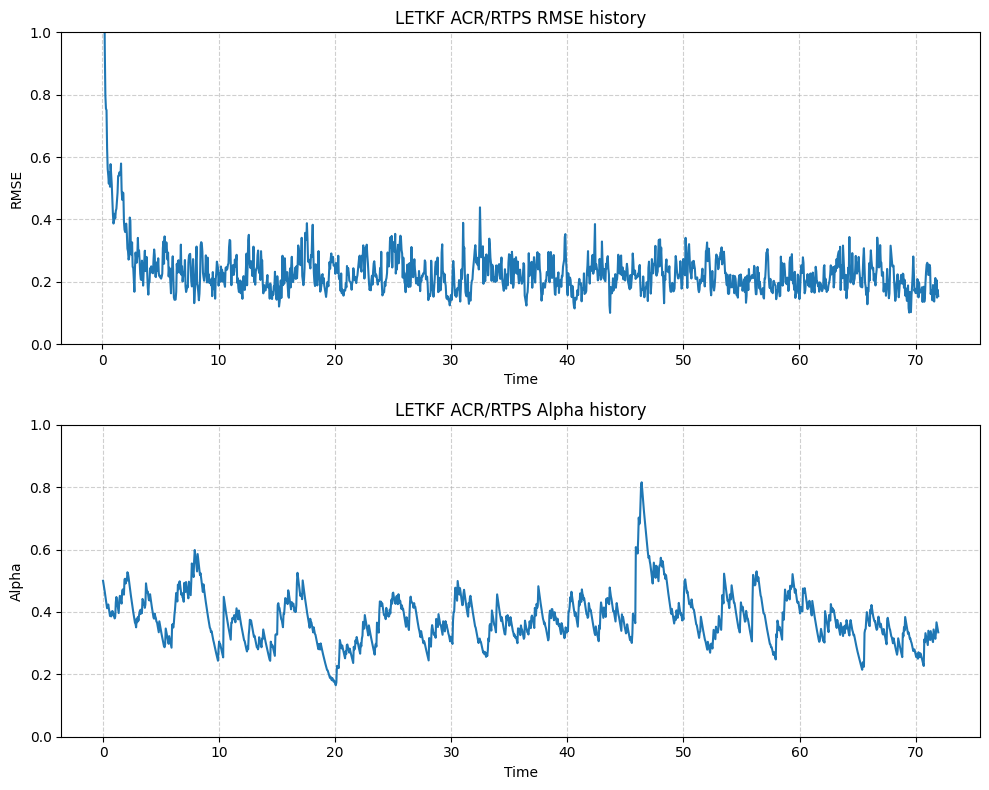

Mean RMSE (LETKF ACR/RTPS): 0.23271319236692062
Mean alpha (LETKF ACR/RTPS): 0.3774259088643004


In [62]:
sigma_loc = 4.0
history_letkf_rtps, alpha_letkf_rtps, rmse_letkf_rtps = run_letkf_acr_rtps(
    ensemble_init=ensemble_init,
    y_observe=y_observe,
    x_truth=x_truth,
    t_truth=t_truth,
    H=H,
    R_inv=R_inv,
    sigma_loc=sigma_loc,
    F=F,
    inflation=0.0,
    initial_alpha=0.5,
    tau=0.03,
)

plot_rmse_and_alpha_subplots(
    t_truth=t_truth,
    rmse_history=rmse_letkf_rtps,
    alpha_history=alpha_letkf_rtps,
    title_prefix="LETKF ACR/RTPS",
)
print("Mean RMSE (LETKF ACR/RTPS):", np.mean(rmse_letkf_rtps))
print("Mean alpha (LETKF ACR/RTPS):", np.mean(alpha_letkf_rtps[1:]))

In [32]:
fixed_rtps_results = {}

for alpha in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    history, alpha_history, rmse_history = run_letkf_fixed_rtps(
        ensemble_init=ensemble_init,
        y_observe=y_observe,
        x_truth=x_truth,
        t_truth=t_truth,
        H=H,
        R_inv=R_inv,
        sigma_loc=sigma_loc,
        F=F,
        inflation=0.0,
        alpha=alpha,
    )

    fixed_rtps_results[alpha] = {
        "history_X_analysis": history,
        "alpha_history": alpha_history,
        "rmse_history": rmse_history,
        "mean_rmse": np.mean(rmse_history),
    }

for alpha, result in fixed_rtps_results.items():
    print(f"alpha={alpha:.1f}, Mean RMSE={result['mean_rmse']:.4f}")

alpha=0.0, Mean RMSE=3.6719
alpha=0.2, Mean RMSE=0.2285
alpha=0.4, Mean RMSE=0.2352
alpha=0.6, Mean RMSE=0.2835
alpha=0.8, Mean RMSE=0.4085
alpha=1.0, Mean RMSE=1.1148


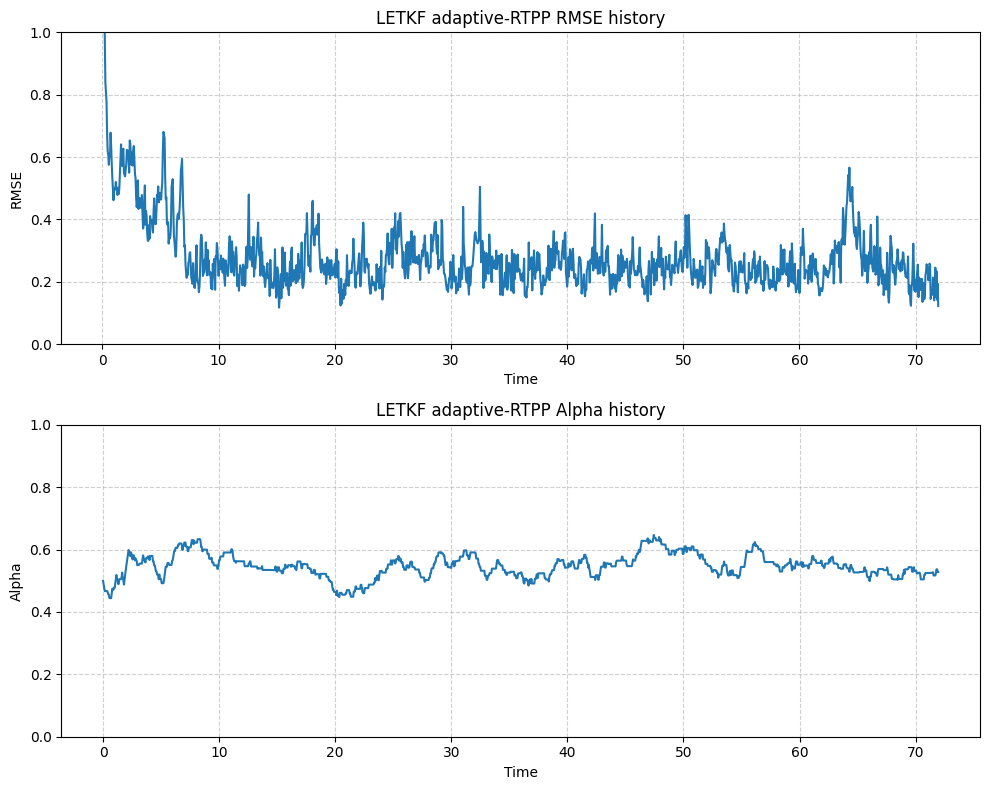

Mean RMSE (LETKF adaptive-RTPP): 0.2780811988727964
Mean alpha (LETKF adaptive-RTPP): 0.5468641486521604


In [65]:
history_letkf_rtpp, alpha_letkf_rtpp, rmse_letkf_rtpp = run_letkf_adaptive_rtpp(
    ensemble_init=ensemble_init,
    y_observe=y_observe,
    x_truth=x_truth,
    t_truth=t_truth,
    H=H,
    R_inv=R_inv,
    sigma_loc=sigma_loc,
    F=F,
    alpha_max=1.0,
    alpha_min=0.0,
    inflation=0.0,
    initial_alpha=0.5,
    tau=0.03,
)

plot_rmse_and_alpha_subplots(
    t_truth=t_truth,
    rmse_history=rmse_letkf_rtpp,
    alpha_history=alpha_letkf_rtpp,
    title_prefix="LETKF adaptive-RTPP",
)

print("Mean RMSE (LETKF adaptive-RTPP):", np.mean(rmse_letkf_rtpp))
print("Mean alpha (LETKF adaptive-RTPP):", np.mean(alpha_letkf_rtpp[1:]))

In [30]:
fixed_rtpp_results = {}

for alpha in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    history, alpha_history, rmse_history = run_letkf_fixed_rtpp(
        ensemble_init=ensemble_init,
        y_observe=y_observe,
        x_truth=x_truth,
        t_truth=t_truth,
        H=H,
        R_inv=R_inv,
        sigma_loc=sigma_loc,
        F=F,
        inflation=0.0,
        alpha=alpha,
    )

    fixed_rtpp_results[alpha] = {
        "history_X_analysis": history,
        "alpha_history": alpha_history,
        "rmse_history": rmse_history,
        "mean_rmse": np.mean(rmse_history),
    }

for alpha, result in fixed_rtpp_results.items():
    print(f"alpha={alpha:.1f}, Mean RMSE={result['mean_rmse']:.4f}")

alpha=0.0, Mean RMSE=3.6719
alpha=0.2, Mean RMSE=0.2780
alpha=0.4, Mean RMSE=0.2593
alpha=0.6, Mean RMSE=0.2578
alpha=0.8, Mean RMSE=0.3642
alpha=1.0, Mean RMSE=1.7485


In [ ]:
# 観測数を20（前半半分: Landのみ）に設定
p_dense = 20  
H_dense = np.eye(N)[:p_dense, :]
R_dense = np.eye(p_dense) * 1.0
R_inv_dense = np.linalg.inv(R_dense)

# すでに生成済みの y_observe (N次元) から、前半20個の観測データだけを切り出す
y_observe_dense = y_observe[:, :p_dense]